In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Acer\Desktop\Sample-Superstore.csv", encoding='latin1')

# Superstore Sales Analysis

## Dataset Overview

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,11/9/2013,11/12/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,11/9/2013,11/12/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,10/11/2012,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,10/11/2012,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']= pd.to_datetime(df['Ship Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:
df['Year'] = df['Order Date'].dt.year
df['Month']= df['Order Date'].dt.month_name()

In [8]:
df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2013-11-09,2013,November
1,2013-11-09,2013,November
2,2013-06-13,2013,June
3,2012-10-11,2012,October
4,2012-10-11,2012,October


## Monthly Sales Analysis

In [10]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.sort_values(ascending=False)

Month
November     349120.0740
December     332177.1595
September    309770.0997
March        199252.9840
October      197115.2017
August       159589.4510
May          156122.2867
July         149580.8380
June         147082.6113
April        141851.5674
January       95365.9376
February      60172.6494
Name: Sales, dtype: float64

In [11]:
monthly_profit = df.groupby('Month')['Profit'].sum()
monthly_profit.sort_values(ascending=False)

Month
December     43436.1339
September    37293.1925
November     35825.5366
October      31469.6638
March        26806.5737
May          22308.5128
August       21896.7154
June         20899.3345
July         13535.3830
April        13437.8068
February     10288.8987
January       9199.2700
Name: Profit, dtype: float64

## 
Monthly sales and monthly profit trends do not completely align across the year. While November generated the highest sales volume, December and September produced comparatively stronger profitability. This may suggest that certain high-sales periods rely more heavily on discounts or lower-margin products, whereas other months achieve better profit efficiency despite lower sales volume.

In [13]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896,2012.722934
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2011.000000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2012.000000
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2013.000000
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2014.000000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2014.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.124039



The mean profit(28.65) is higher than the median(8.66), indicating the presence of extreme values affecting the average. The wide range between the minimum(-6599.97) and maximum(8399.97) profits suggests that profitability is highly uneven across transactions, with outliers strongly influencing overall results. 

## Profitability Analysis

In [18]:
df[df['Profit'] == df['Profit'].min()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
7772,7773,CA-2013-108196,2013-11-26,2013-12-03,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.978,2013,November


In [19]:
df[df['Profit'] == df['Profit'].max()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
6826,6827,CA-2013-118689,2013-10-03,2013-10-10,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.95,5,0.0,8399.976,2013,October


## 
Technology products showed both the highest and lowest profit extremes in the datatset. Interestingly, both the Canon Copier and and Cubify Printer were sold in the same quantity, yet their profit outcomes differed drastically. The Cubify Printer carried a very huge discount rate of 70%, resulting in a major financial loss, whereas the Canon Copier generated extremely high profit without discounting. This may suggests that aggressive discounting on high-value technology products can severly impact profitability when pricing balance is not optimized carefully. 

In [21]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [22]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [23]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [24]:
df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64

##                                  
Sub-categories such as Binders, Machines, Tables and Bookcases received some of the highest average discount rates across the dataset. However, Machines, Tables, and Bookcases showed negative profitbality outcomes, whereas Binders remained strongly profitable despite heavy discounting. This may suggest certain products are able to sustain discount strategies more effectively due to stronger pricing balance or healthier profit margins compared to higher-value products with greater financial risk exposure.  

In [26]:
df['Discount'].corr(df['Profit'])

-0.21948745637176806

## Data Visualization

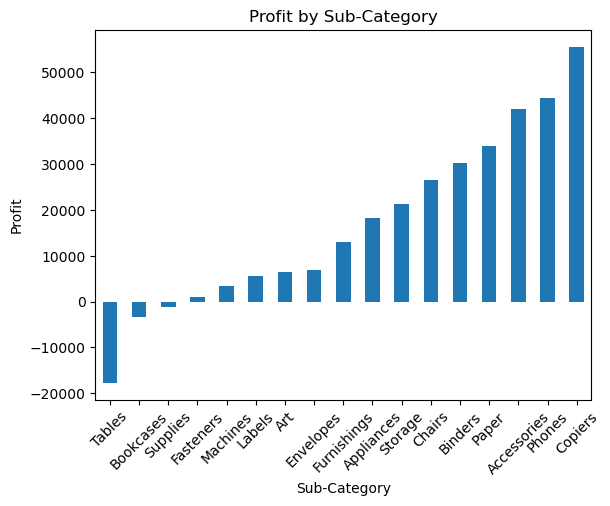

In [28]:
import matplotlib.pyplot as plt

df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='bar')

plt.title('Profit by Sub-Category')
plt.ylabel('Profit')
plt.xlabel('Sub-Category')

plt.xticks(rotation=45)

plt.show()

## 
Tables and Bookcases generated significant losses despite likely strong sales activity. Their relatively higher average discount rates may have negatively impacted overall profitability. In contrast, products such as Papers and Binders remained profitable even under discount conditions, which may indicate stronger profit margins or more sustainable pricing structures. 

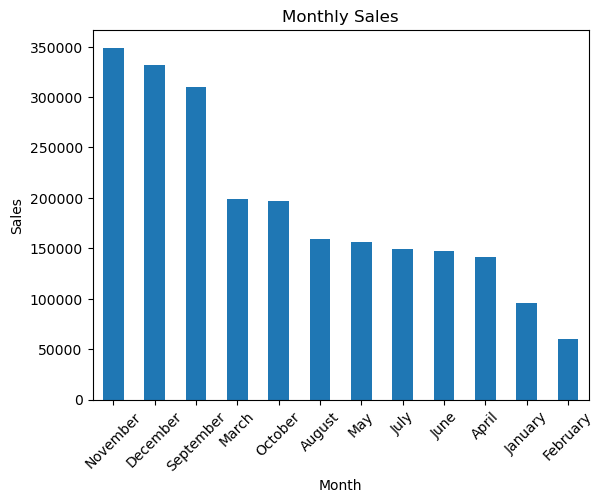

In [30]:
monthly_sales.sort_values(ascending=False).plot(kind='bar')

plt.title('Monthly Sales')
plt.ylabel('Sales')
plt.xlabel('Month')

plt.xticks(rotation=45)

plt.show()

##
Sales peaked during November and December suggesting seasonal purchasing behavior near year-end.

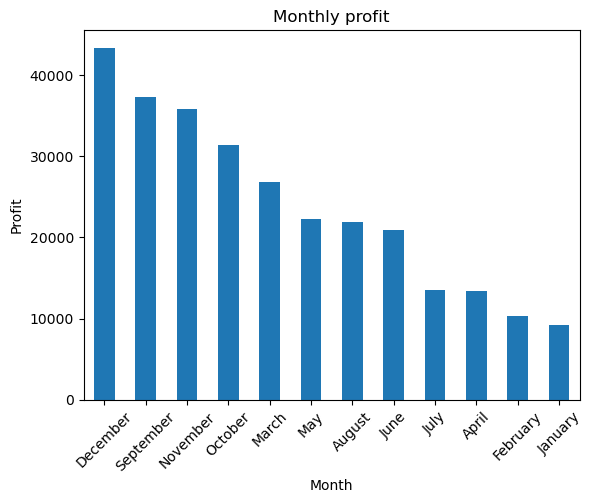

In [32]:
monthly_profit.sort_values(ascending=False).plot(kind='bar')

plt.title('Monthly profit')
plt.ylabel('Profit')
plt.xlabel('Month')

plt.xticks(rotation=45)

plt.show()

##
Monthly profit trends differ slightly from monthly sales patterns. While November generated the highest sales volume, December and September produced stronger profitability performance. This may suggest that some high-sales periods rely more heavily on discounts or lower-margin products, whereas other months achieve stronger profit efficiency. 

## Conclusion

- Technology and offcie supplies generated the strongest overall profits across the business, showing more stable profitability compared to certain furniture products.
- Tables and Bookcases produced major losses despite sales activity.
- Higher discount rates showed a negative relationship with profitability.
- November and December demonstrated strong seasonal sales performance.
- Discount strategies may require effective optimization to improve long term margins.